In [3]:
# Load Table 2A baseline returns as a 3x4 NumPy matrix
import numpy as np

baseline_returns = np.array([
    [2.07, 1.49, 1.21, 1.44],  # Western
    [3.70, 3.11, 1.61, 2.74],  # Central
    [1.10, 1.72, 1.78, 1.96],  # Eastern
])



# 1. Recreating Mallory and Ando & Testing utiltiy functions. 
In this section we have 
- Recreating efficient frontier and optimal portfolios for linearly interpolated returns between the current and projected future returns in the paper. 

- Trying to see how the optimal portfolio compares when maximizing the expected utility functions with varying risk aversion parameter. Try with CRRA and mena-variance utility.



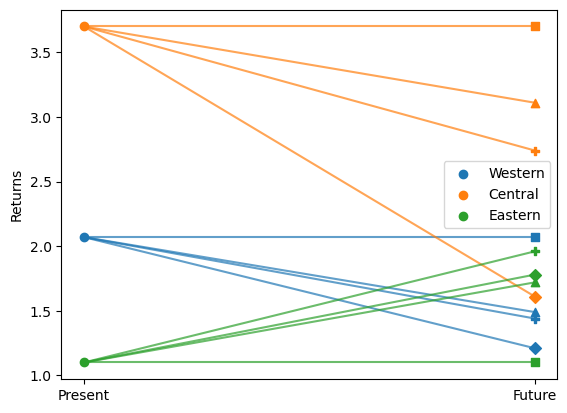

In [4]:
# Visualize historical vs future scenarios with connecting lines per region
import matplotlib.pyplot as plt
regions = ['Western', 'Central', 'Eastern']

historical_marker = 'o'  # Present value at x=0
scenario_markers = ['s', '^', 'D', 'P']  # Future markers for columns 0,1,2,3

for i, region in enumerate(regions):
    historical = baseline_returns[i][0]
    future_values = baseline_returns[i]

    # Plot the historical point and keep the color for matching future points/lines
    scatter = plt.scatter([0], [historical], marker=historical_marker, label=region)
    color = scatter.get_facecolor()[0]

    # Plot each future value with a marker based on its column index
    for j, f in enumerate(future_values):
        plt.scatter([1], [f], marker=scenario_markers[j], color=color)
        plt.plot([0, 1], [historical, f], color=color, alpha=0.7)

plt.xticks([0, 1], ['Present', 'Future'])
plt.ylabel('Returns')
plt.legend()
plt.show()


In [5]:
# make multiple timesteps returns for each region
# Load Table 2A baseline returns as a 3x4 NumPy matrix
import numpy as np

baseline_returns = np.array([
    [2.07, 1.49, 1.21, 1.44],  # Western
    [3.70, 3.11, 1.61, 2.74],  # Central
    [1.10, 1.72, 1.78, 1.96],  # Eastern
])

timesteps = 10
multi_timestep_returns = np.zeros((timesteps,) + baseline_returns.shape)
multi_timestep_returns[-1] = baseline_returns

multi_timestep_returns[0] = np.tile(baseline_returns[:, 0], (4, 1)).T  # stack 0th col 4 times
# linear interpolation between the historical 0th column and the final baseline returns
historical_col = baseline_returns[:, 0][:, np.newaxis]
for t in range(1, timesteps - 1):
    multi_timestep_returns[t] = historical_col + (baseline_returns - historical_col) * t / (timesteps - 1)


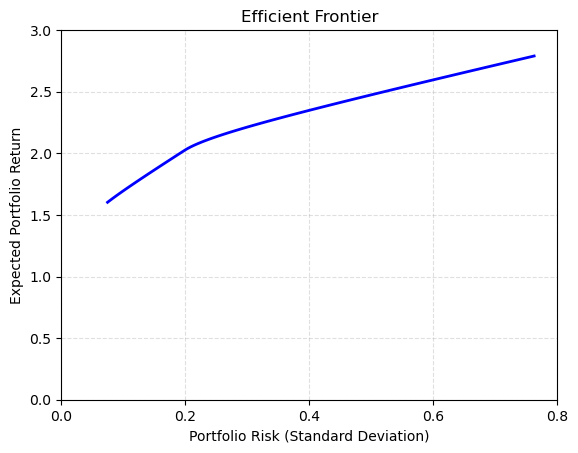

In [6]:
# test mpt solver on final returns data
from MPTsolver import MPTsolver
import matplotlib.pyplot as plt
import numpy as np

mpt = MPTsolver(multi_timestep_returns[-1])
frontier, weights = mpt.get_efficient_frontier(numportfolios=100)

# plot efficient frontier
plt.plot(frontier[:, 1], frontier[:, 0], 'b-', linewidth=2)
plt.xlabel('Portfolio Risk (Standard Deviation)')
plt.ylabel('Expected Portfolio Return')
plt.title('Efficient Frontier')

# Set ticks at fixed intervals
x_max = frontier[:, 1].max()
y_max = frontier[:, 0].max()
plt.xticks(np.arange(0, x_max + 0.2, 0.2))
plt.yticks(np.arange(0, y_max + 0.5, 0.5))

# Add grid lines
plt.grid(True, which='major', linestyle='--', alpha=0.4)

plt.show()




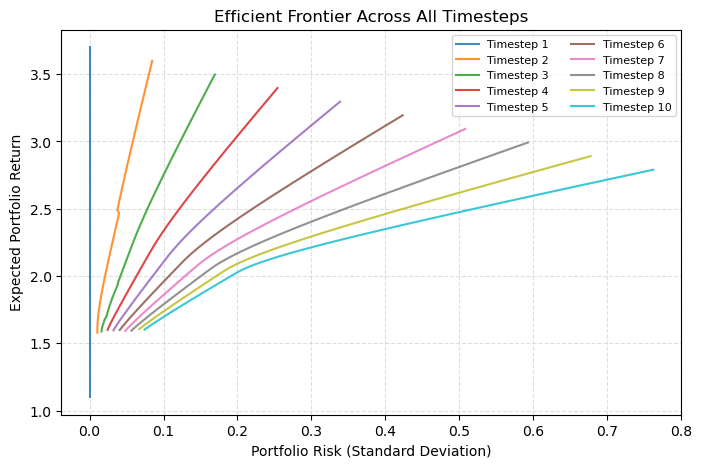

In [7]:
# Plot efficient frontier for every timestep
import numpy as np
import matplotlib.pyplot as plt
from MPTsolver import MPTsolver

all_frontiers = []
all_weights = []

plt.figure(figsize=(8, 5))
for t in range(multi_timestep_returns.shape[0]):
    mpt_t = MPTsolver(multi_timestep_returns[t])
    frontier_t, weights_t = mpt_t.get_efficient_frontier(numportfolios=100)
    all_frontiers.append(frontier_t)
    all_weights.append(weights_t)

    plt.plot(
        frontier_t[:, 1],
        frontier_t[:, 0],
        linewidth=1.5,
        alpha=0.85,
        label=f'Timestep {t + 1}'
    )

plt.xlabel('Portfolio Risk (Standard Deviation)')
plt.ylabel('Expected Portfolio Return')
plt.title('Efficient Frontier Across All Timesteps')
plt.grid(True, which='major', linestyle='--', alpha=0.4)
plt.legend(ncol=2, fontsize=8)
plt.show()

In [ ]:
# Plot portfolio shares across regions vs risk for selected timesteps
import numpy as np
import matplotlib.pyplot as plt
from MPTsolver import MPTsolver

# load ando data

baseline_returns = np.array([
    [2.07, 1.49, 1.21, 1.44],  # Western
    [3.70, 3.11, 1.61, 2.74],  # Central
    [1.10, 1.72, 1.78, 1.96],  # Eastern
])
baseline_returns[1] = baseline_returns[1] - 1.1  # altering central region values to make it more comparable
print(baseline_returns)
timesteps = 10
multi_timestep_returns = np.zeros((timesteps,) + baseline_returns.shape)
multi_timestep_returns[-1] = baseline_returns

multi_timestep_returns[0] = np.tile(baseline_returns[:, 0], (4, 1)).T  # stack 0th col 4 times
# linear interpolation between the historical 0th column and the final baseline returns
historical_col = baseline_returns[:, 0][:, np.newaxis]
for t in range(1, timesteps - 1):
    multi_timestep_returns[t] = historical_col + (baseline_returns - historical_col) * t / (timesteps - 1)


# Recompute if Cell 5 was not run
if 'all_frontiers' not in globals() or 'all_weights' not in globals() or len(all_frontiers) != multi_timestep_returns.shape[0]:
    all_frontiers = []
    all_weights = []
    for t in range(multi_timestep_returns.shape[0]):
        mpt_t = MPTsolver(multi_timestep_returns[t])
        frontier_t, weights_t = mpt_t.get_efficient_frontier(numportfolios=100)
        all_frontiers.append(frontier_t)
        all_weights.append(weights_t)

regions = ['Western', 'Central', 'Eastern']
n_steps = multi_timestep_returns.shape[0]

# Plot all timesteps (1-based labels for display)
featured_timesteps = list(range(1, n_steps + 1))
selected_timesteps = [t - 1 for t in featured_timesteps]
titles = [f'Timestep {t}' for t in featured_timesteps]

# Common y-axis ticks for every subplot
y_ticks = np.arange(0, 1.01, 0.2)

# Build a grid layout that scales with number of timesteps
n_cols = 5
n_rows = int(np.ceil(len(selected_timesteps) / n_cols))
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3.5 * n_rows),
    sharey=True,
    sharex=False
    )
axes = np.atleast_1d(axes).ravel()

for ax, t_idx, title in zip(axes, selected_timesteps, titles):
    frontier_t = all_frontiers[t_idx]
    weights_t = np.array(all_weights[t_idx])

    for r, region in enumerate(regions):
        ax.plot(frontier_t[:, 1], weights_t[:, r], linewidth=2, label=region)

    # Use per-subplot x ticks based on that subplot's risk range
    x_ticks = np.linspace(0, frontier_t[:, 1].max(), 6)
    ax.set_title(title)
    ax.set_xlabel('Portfolio Risk (Standard Deviation)')
    ax.set_ylim(0, 1)
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)
    ax.tick_params(axis='both', labelbottom=True, labelleft=True)
    ax.grid(True, which='major', linestyle='--', alpha=0.4)

# Hide any unused axes in the grid
for ax in axes[len(selected_timesteps):]:
    ax.set_visible(False)

axes[0].set_ylabel('Portfolio Share')
fig.legend(regions, loc='upper right')
plt.suptitle('Portfolio Shares by Region vs Portfolio Risk (All Timesteps)')
plt.tight_layout()
plt.show()

[[2.07 1.49 1.21 1.44]
 [2.6  2.01 0.51 1.64]
 [1.1  1.72 1.78 1.96]]


[[2.07 1.49 1.21 1.44]
 [2.5  1.91 0.41 1.54]
 [1.1  1.72 1.78 1.96]]


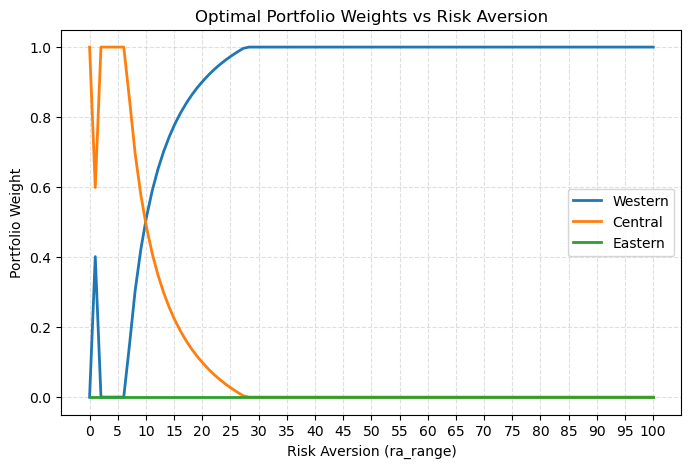

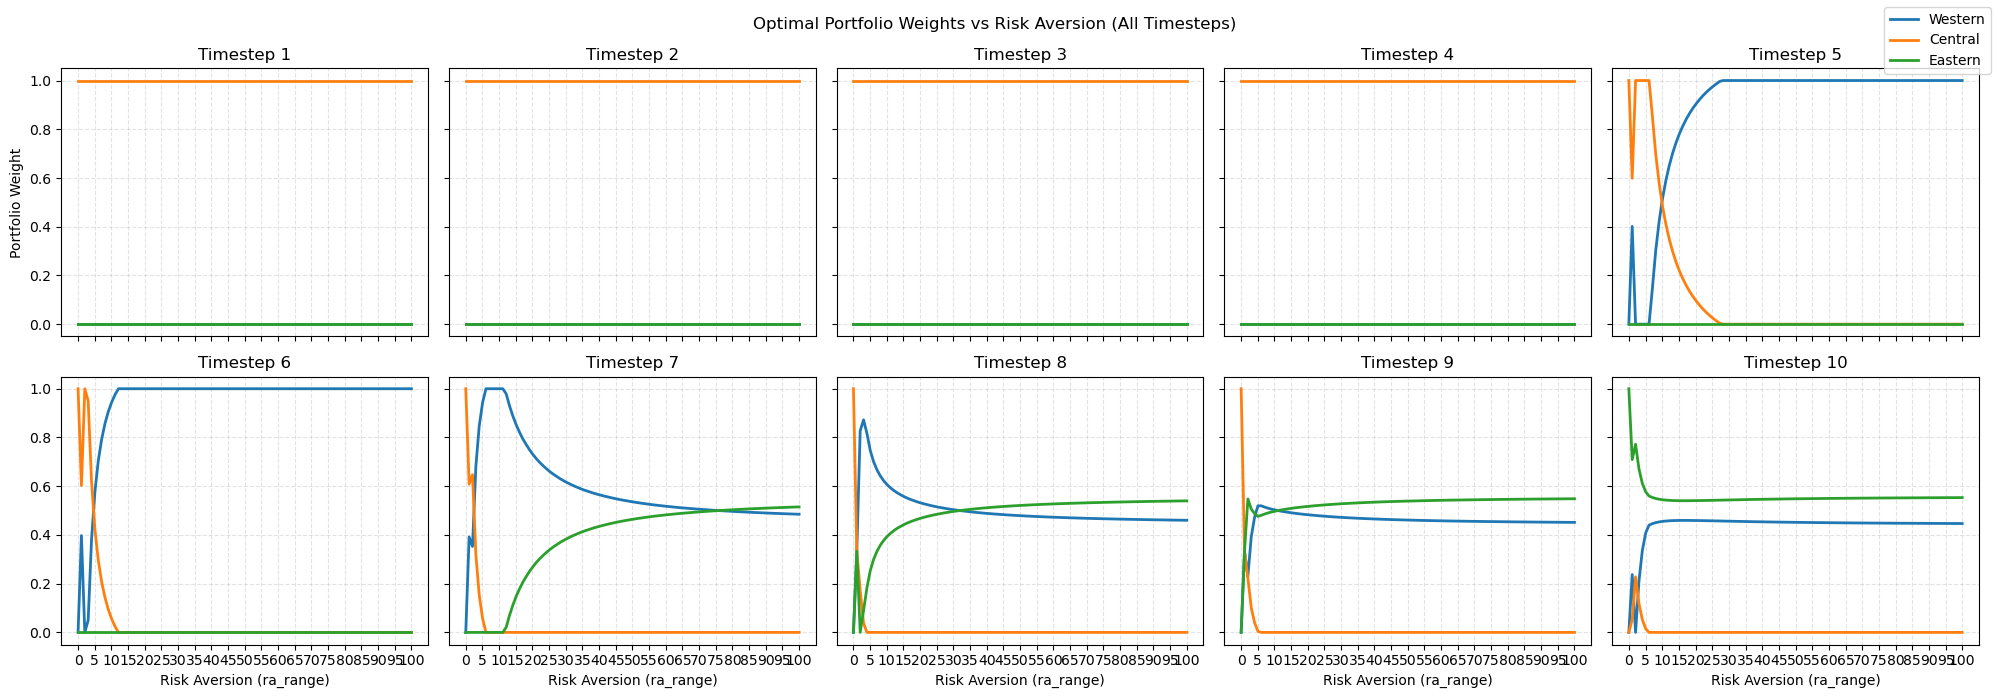

In [4]:
# utility maximization (crra utility) portfolio optimization
from utilitysolver import utilitysolver
import numpy as np
import matplotlib.pyplot as plt
# load ando data
central_adjustment = 1.2
baseline_returns = np.array([
    [2.07, 1.49, 1.21, 1.44],  # Western
    [3.70, 3.11, 1.61, 2.74],  # Central
    [1.10, 1.72, 1.78, 1.96],  # Eastern
])
baseline_returns[1] = baseline_returns[1] - central_adjustment # altering central region values to make it more comparable
print(baseline_returns)
timesteps = 10
multi_timestep_returns = np.zeros((timesteps,) + baseline_returns.shape)
multi_timestep_returns[-1] = baseline_returns

multi_timestep_returns[0] = np.tile(baseline_returns[:, 0], (4, 1)).T  # stack 0th col 4 times
# linear interpolation between the historical 0th column and the final baseline returns
historical_col = baseline_returns[:, 0][:, np.newaxis]
for t in range(1, timesteps - 1):
    multi_timestep_returns[t] = historical_col + (baseline_returns - historical_col) * t / (timesteps - 1)


ra_range = np.linspace(0, 100, 100)
weights_over_ra = []
max_u_over_ra = []
selected_timestep = 4

for ra in ra_range:
    solver = utilitysolver(risk_aversion=ra)
    max_u, w = solver.max_utility(multi_timestep_returns[selected_timestep])
    #print(f"Risk aversion: {ra}")
    #print("Max expected utility:", max_u)
    #print("Optimal weights:", w)
    #print('\n')

    max_u_over_ra.append(max_u)
    weights_over_ra.append(w)

weights_over_ra = np.array(weights_over_ra)  # shape: (len(ra_range), 3)
max_u_over_ra = np.array(max_u_over_ra)    # shape: (len(ra_range),)
regions = ['Western', 'Central', 'Eastern']
 
plt.figure(figsize=(8, 5))
for i, region in enumerate(regions):
    plt.plot(ra_range, weights_over_ra[:, i], linewidth=2, label=region)

# Set x-axis major ticks at increments of 5
x_min = np.floor(ra_range.min() / 5) * 5
x_max = np.ceil(ra_range.max() / 5) * 5
plt.xticks(np.arange(x_min, x_max + 5, 5))

plt.xlabel('Risk Aversion (ra_range)')
plt.ylabel('Portfolio Weight')
plt.title('Optimal Portfolio Weights vs Risk Aversion')
plt.grid(True, which='major', linestyle='--', alpha=0.4)
plt.legend()
plt.show()

# Additional figure: weights vs risk aversion for all timesteps (1-based labels)
n_steps = multi_timestep_returns.shape[0]
n_regions = len(regions)
all_weights_over_ra = np.zeros((n_steps, len(ra_range), n_regions))

for t_idx in range(n_steps):
    for r_idx, ra in enumerate(ra_range):
        solver = utilitysolver(risk_aversion=ra)
        _, w = solver.max_utility(multi_timestep_returns[t_idx])
        all_weights_over_ra[t_idx, r_idx, :] = w

n_cols = 5
n_rows = int(np.ceil(n_steps / n_cols))
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3.5 * n_rows),
    sharex=True,
    sharey=True
    )
axes = np.atleast_1d(axes).ravel()

for t_idx in range(n_steps):
    ax = axes[t_idx]
    for i, region in enumerate(regions):
        ax.plot(ra_range, all_weights_over_ra[t_idx, :, i], linewidth=2, label=region)
    ax.set_title(f'Timestep {t_idx + 1}')
    ax.set_xticks(np.arange(x_min, x_max + 5, 5))
    ax.grid(True, which='major', linestyle='--', alpha=0.35)

for ax in axes[n_steps:]:
    ax.set_visible(False)

axes[0].set_ylabel('Portfolio Weight')
for ax in axes[-n_cols:]:
    if ax.get_visible():
        ax.set_xlabel('Risk Aversion (ra_range)')

fig.legend(regions, loc='upper right')
plt.suptitle('Optimal Portfolio Weights vs Risk Aversion (All Timesteps)')
plt.tight_layout()
plt.show()

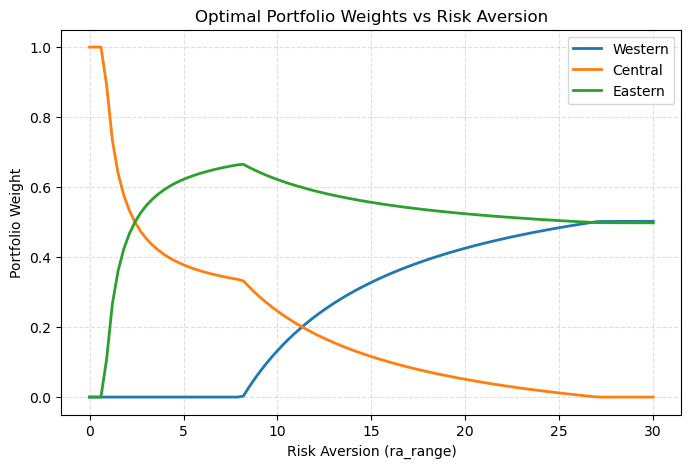

In [ ]:
from utilitysolver2 import utilitysolver
import numpy as np
import matplotlib.pyplot as plt
baseline_returns = np.array([
    [2.07, 1.49, 1.21, 1.44],  # Western
    [3.70, 3.11, 1.61, 2.74],  # Central
    [1.10, 1.72, 1.78, 1.96],  # Eastern
])

timesteps = 1000
multi_timestep_returns = np.zeros((timesteps,) + baseline_returns.shape)
multi_timestep_returns[-1] = baseline_returns

multi_timestep_returns[0] = np.tile(baseline_returns[:, 0], (4, 1)).T  # stack 0th col 4 times
# linear interpolation between the historical 0th column and the final baseline returns
historical_col = baseline_returns[:, 0][:, np.newaxis]
for t in range(1, timesteps - 1):
    multi_timestep_returns[t] = historical_col + (baseline_returns - historical_col) * t / (timesteps - 1)

ra_range = np.linspace(0, 30, 100)
weights_over_ra = []
max_u_over_ra = []
selected_timestep = -1
for ra in ra_range:
    solver = utilitysolver(risk_aversion=ra)
    max_u, w = solver.max_utility(multi_timestep_returns[selected_timestep])
    max_u_over_ra.append(max_u)
    weights_over_ra.append(w)

weights_over_ra = np.array(weights_over_ra)  # shape: (len(ra_range), 3)
regions = ['Western', 'Central', 'Eastern']

plt.figure(figsize=(8, 5))
for i, region in enumerate(regions):
    plt.plot(ra_range, weights_over_ra[:, i], linewidth=2, label=region)

plt.xlabel('Risk Aversion (ra_range)')
plt.ylabel('Portfolio Weight')
plt.title('Optimal Portfolio Weights vs Risk Aversion')
plt.grid(True, which='major', linestyle='--', alpha=0.4)
plt.legend()
plt.show()

# 2. Making a dynamic model from Mallory and Ando

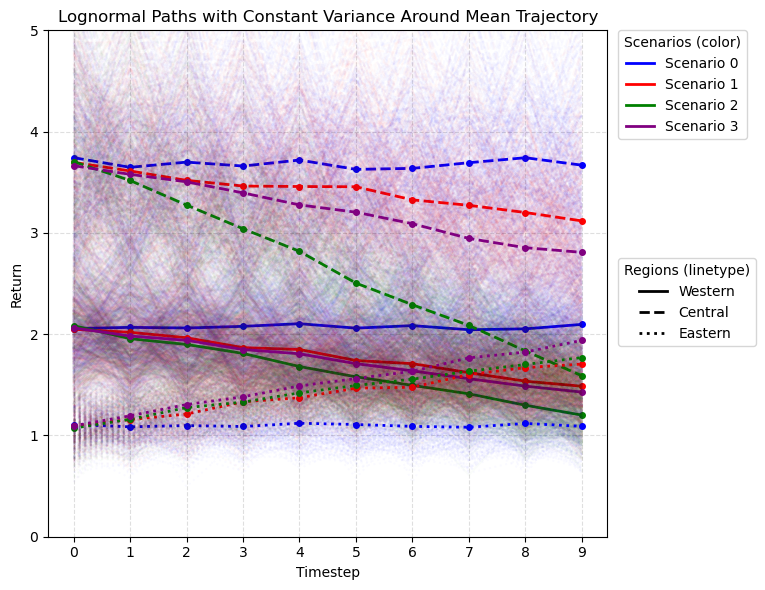

In [14]:
# Simulate paths that transition from present to future levels (consistent with Cell 3)
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# load data
baseline_returns = np.array([
    [2.07, 1.49, 1.21, 1.44],  # Western
    [3.70, 3.11, 1.61, 2.74],  # Central
    [1.10, 1.72, 1.78, 1.96],  # Eastern
])  # col 0: historical, col 1-3: future scenarios
central_adjustment = 0
baseline_returns[1] = baseline_returns[1] - central_adjustment

timesteps = 10
multi_timestep_returns = np.zeros((timesteps,) + baseline_returns.shape)
multi_timestep_returns[-1] = baseline_returns

multi_timestep_returns[0] = np.tile(baseline_returns[:, 0], (4, 1)).T
historical_col = baseline_returns[:, 0][:, np.newaxis]
for t in range(1, timesteps - 1):
    multi_timestep_returns[t] = historical_col + (baseline_returns - historical_col) * t / (timesteps - 1)

# Lognormal simulations around mean path with constant variance (Section 3.2 style)
num_simulations = 300
sigma_logn = 0.2  # constant std dev in log space across all timesteps/regions/scenarios
mean_path = np.clip(multi_timestep_returns, 1e-6, None)
log_mu = np.log(mean_path) - 0.5 * sigma_logn**2

simulations = np.random.lognormal(
    mean=log_mu[..., np.newaxis],
    sigma=sigma_logn,
    size=(timesteps,) + baseline_returns.shape + (num_simulations,)
    )

# Plot mean path per region/scenario plus faint simulation paths
plt.figure(figsize=(10, 6))
scenario_colors = ['blue', 'red', 'green', 'purple']
region_linetype = ['-', '--', ':']
region_names = ['Western', 'Central', 'Eastern']
x = np.arange(timesteps)

for region in range(baseline_returns.shape[0]):
    for scenario in range(baseline_returns.shape[1]):
        for i in range(num_simulations):
            plt.plot(
                x,
                simulations[:, region, scenario, i],
                color=scenario_colors[scenario],
                alpha=0.02,
                linestyle=region_linetype[region]
            )
        plt.plot(
            x,
            simulations[:, region, scenario, :].mean(axis=1),
            color=scenario_colors[scenario],
            linestyle=region_linetype[region],
            linewidth=2,
            marker='o',
            markersize=4
        )

# Separate legends: colors for scenarios, linetypes for regions
scenario_handles = [
    Line2D([0], [0], color=scenario_colors[s], lw=2, label=f'Scenario {s}')
    for s in range(baseline_returns.shape[1])
]
region_handles = [
    Line2D([0], [0], color='black', lw=2, linestyle=region_linetype[r], label=region_names[r])
    for r in range(baseline_returns.shape[0])
]

ax = plt.gca()
legend_scenarios = ax.legend(
    handles=scenario_handles,
    title='Scenarios (color)',
    loc='upper left',
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0
)
ax.add_artist(legend_scenarios)
ax.legend(
    handles=region_handles,
    title='Regions (linetype)',
    loc='upper left',
    bbox_to_anchor=(1.02, 0.55),
    borderaxespad=0.0
)
plt.ylim(0,5)
plt.xlabel('Timestep')
plt.ylabel('Return')
plt.title('Lognormal Paths with Constant Variance Around Mean Trajectory')
plt.xticks(x)
plt.grid(True, which='major', linestyle='--', alpha=0.4)
plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()

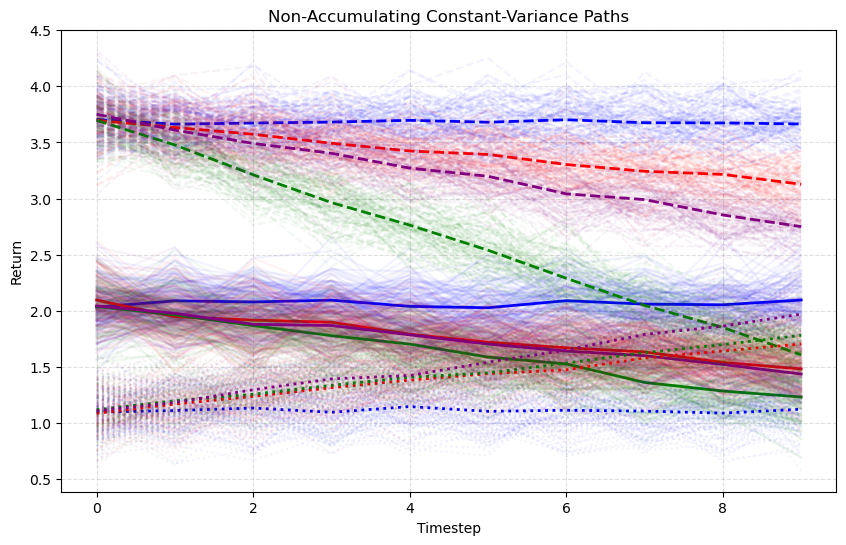

In [ ]:
# Non-accumulating version: constant variance at each timestep around the mean path
import matplotlib.pyplot as plt
import numpy as np

# Reuse existing baseline_returns / multi_timestep_returns if available
if 'multi_timestep_returns' not in globals():
    baseline_returns = np.array([
        [2.07, 1.49, 1.21, 1.44],
        [3.70, 3.11, 1.61, 2.74],
        [1.10, 1.72, 1.78, 1.96],
    ])
    timesteps = 10
    multi_timestep_returns = np.zeros((timesteps,) + baseline_returns.shape)
    multi_timestep_returns[-1] = baseline_returns
    multi_timestep_returns[0] = np.tile(baseline_returns[:, 0], (4, 1)).T
    historical_col = baseline_returns[:, 0][:, np.newaxis]
    for t in range(1, timesteps - 1):
        multi_timestep_returns[t] = historical_col + (baseline_returns - historical_col) * t / (timesteps - 1)

timesteps = multi_timestep_returns.shape[0]
n_regions, n_scenarios = multi_timestep_returns.shape[1], multi_timestep_returns.shape[2]
num_simulations = 100
sigma_const = 0.2

# Each timestep is sampled independently: X_t = mean_t + sigma * epsilon_t
noise = np.random.normal(0, sigma_const, size=(timesteps, n_regions, n_scenarios, num_simulations))
simulations_const = multi_timestep_returns[..., np.newaxis] + noise

plt.figure(figsize=(10, 6))
scenario_colors = ['blue', 'red', 'green', 'purple']
region_linetype = ['-', '--', ':']

for region in range(n_regions):
    for scenario in range(n_scenarios):
        for i in range(num_simulations):
            plt.plot(
                simulations_const[:, region, scenario, i],
                color=scenario_colors[scenario],
                alpha=0.05,
                linestyle=region_linetype[region]
            )
        plt.plot(
            simulations_const[:, region, scenario, :].mean(axis=1),
            color=scenario_colors[scenario],
            linestyle=region_linetype[region],
            linewidth=2
        )

plt.xlabel('Timestep')
plt.ylabel('Return')
plt.title('Non-Accumulating Constant-Variance Paths')
plt.grid(True, which='major', linestyle='--', alpha=0.4)
plt.show()

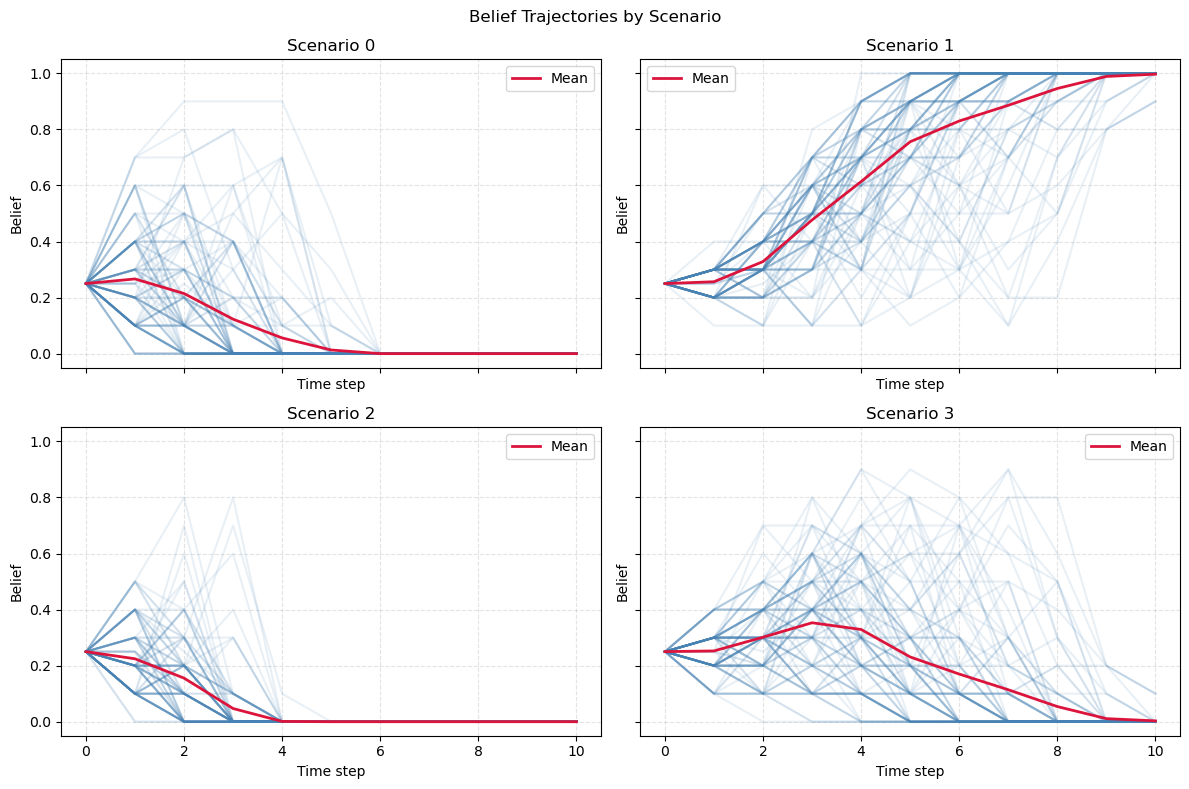

In [19]:
from pprdyn1 import *
import numpy as np
import matplotlib.pyplot as plt

env = pprdyn1({'settingID': 11})
testing_scenario = 1
episodenum = 100
beliefs = np.zeros((episodenum, env.n_scenario, env.T + 1))

for i in range(episodenum):
    env.reset(scenario=testing_scenario)
    done = False
    beliefs[i, :, 0] = env.state[env.sidx['b']]
    while not done:
        action = 0
        obs, reward, done, info = env.step(action)
        beliefs[i, :, int(env.state[env.sidx['t']].item())] = env.state[env.sidx['b']]

# Plot all scenarios in a 2x2 grid
n_scenarios = env.n_scenario
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

for s in range(n_scenarios):
    ax = axes[s]
    for i in range(episodenum):
        ax.plot(range(env.T + 1), beliefs[i, s, :], alpha=0.12, color='steelblue')

    mean_belief = beliefs[:, s, :].mean(axis=0)
    ax.plot(range(env.T + 1), mean_belief, color='crimson', linewidth=2, label='Mean')
    ax.set_title(f'Scenario {s}')
    ax.set_xlabel('Time step')
    ax.set_ylabel('Belief')
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.legend(loc='best')

# Hide any extra axes if scenario count is not 4
for ax in axes[n_scenarios:]:
    ax.set_visible(False)

plt.suptitle('Belief Trajectories by Scenario')
plt.tight_layout()
plt.show()

In [3]:
# evaluate performance of different policies
from pprdyn1 import *
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import pickle
import numpy as np
import pandas as pd
from performance_eval import avgperformance
# from VI_pprdyn1 import _act, build_optimal_controller_fully_observable

config = {'policytype': 0, 'VIenvsetting': 0,'num_episodes': 10000}
settings = {'settingID': 3}
env = pprdyn1(settings)
summary = avgperformance(env,config=config, policy_printout=False,printout = False)


policy type: value iteration
Episode 1000 done
Episode 2000 done
Episode 3000 done
Episode 4000 done
Episode 5000 done
Episode 6000 done
Episode 7000 done
Episode 8000 done
Episode 9000 done
Episode 10000 done
MC log_negV = -8.533102
Average reward over 10000 episodes: -9.5138, certrainty equivalent: 2.6099


In [1]:
for n in [10000, 50000, 100000, 500000]:
    np.random.seed(42)
    config = {'policytype': 4, 'num_episodes': n}
    settings = {'settingID': 5}
    env = pprdyn1(settings)
    summary = avgperformance(env, config)

NameError: name 'np' is not defined

In [ ]:
from VIpprdyn1 import *

vi = VIpprdyn1(settings={'settingID': 12})
vi.precompute_belief_transitions()

Precomputing belief transitions (setting=12)...
